# 02 · Economic Metric Forecasting with Covariates
---
**Purpose**: Extend the univariate SARIMAX approach with:
- External covariates (other metrics whose future values are predicted first)
- Lag or rolling-average features built from the target series
- Recursive forecasting when future covariate values must be generated

**Process overview**:
1. Load config values + actual data + benchmark data
2. Define the covariate dictionary: `{metric_name: lag_offset}`
3. Forecast each covariate individually (Auto-ARIMA by default; override per metric)
4. Build lag or MA feature matrix for the target series
5. Tune SARIMAX on two tuning horizons with the full exog set
6. Select best hyperparameters (half-life decay)
7. Recursive inference forecast with covariates fed step-by-step
8. Plot all horizons


## 1 · Imports

In [108]:
import sys, datetime, warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools

sys.path.insert(0, "./scripts")
from scripts.helpers import (
    load_actual_data, load_benchmark_data,
    build_pred_df, get_benchmark,
    evaluate_pred_df, plot_results, plot_all_horizons,
    print_metrics,
)

from statsmodels.tsa.statespace.sarimax import SARIMAX
from pmdarima import auto_arima
warnings.filterwarnings("ignore")


## 2 · Configuration
All user-facing settings live in the next cell. Update portfolio, metric,
dates, covariate behavior, and benchmark labels there.


In [109]:
# -- Portfolio / metric --------------------------------------------
portfolio     = "Buckeye"
sub_portfolio = "LP"          # set to None if no sub-portfolio
forecast_type = "Actual"
TARGET_METRIC = "Ending Outstanding Loans"

# -- Horizons (general names) --------------------------------------
H_TUNE_1 = {
    "train_start": "2021-12-31",
    "train_end":   "2023-12-31",
    "test_start":  "2024-01-31",
    "test_end":    "2024-12-31",
}
H_TUNE_2 = {
    "train_start": "2022-12-31",
    "train_end":   "2024-12-31",
    "test_start":  "2025-01-31",
    "test_end":    "2025-12-31",
}
H_INFER = {
    "train_start": "2023-12-31",
    "train_end":   "2025-12-31",
    "test_start":  "2026-01-31",
    "test_end":    "2026-12-31",
}

# -- Tuning strategy -----------------------------------------------
WEIGHTED_TUNING = True
TOP_N_TUNE_1    = 20

# -- Paths and benchmark source ------------------------------------
data_dir = "./data"
USE_DUMMY_BENCHMARK = True
DUMMY_BENCHMARK_PATH = "./data/dummy_metrics.csv"

S3_BUCKET   = "fmsp-sagemaker-rstudio-01"
S3_FOLDER   = "Forecasting/Buckeye"
METRICS_FILE = "Forecasting_Buckeye_combined_with_predata_v6.parquet"

# -- Benchmark labels -----------------------------------------------
BENCHMARK_LABELS_TUNE_1 = [
    "2024 0+12",
    "original base case",
]
BENCHMARK_LABELS_TUNE_2 = [
    "2025 0+12",
    "original base case",
]
BENCHMARK_LABELS_INFER = [
    "2026 0+12",
    "original base case",
]

print(f"Portfolio : {portfolio} / {sub_portfolio}")
print(f"Metric    : {TARGET_METRIC}")


Portfolio : Buckeye / LP
Metric    : Ending Outstanding Loans


## 3 · Data Loading

In [110]:
data_df = load_actual_data(data_dir, portfolio, sub_portfolio, forecast_type)

if USE_DUMMY_BENCHMARK:
    metric_df = pd.read_csv(DUMMY_BENCHMARK_PATH)
    metric_df["DATE"] = pd.to_datetime(metric_df["DATE"]).dt.date
else:
    metric_df = load_benchmark_data(
        bucket       = S3_BUCKET,
        folder       = S3_FOLDER,
        metrics_file = METRICS_FILE,
    )

print(f"Actual data: {len(data_df)} rows  ({data_df.index[0]} -> {data_df.index[-1]})")
print(f"Benchmark rows: {len(metric_df)}")


Actual data: 64 rows  (2020-12-31 -> 2026-03-31)
Benchmark rows: 48


## 4 · Horizon Slicing

In [111]:
def build_test_index(horizon: dict) -> pd.Index:
    return pd.date_range(horizon["test_start"], horizon["test_end"], freq="ME").date


def slice_horizon_full(data_df: pd.DataFrame, horizon: dict) -> tuple[pd.DataFrame, pd.DataFrame]:
    train_start = datetime.date.fromisoformat(horizon["train_start"])
    train_end   = datetime.date.fromisoformat(horizon["train_end"])
    train_df = data_df[(data_df.index >= train_start) & (data_df.index <= train_end)]

    test_index = build_test_index(horizon)
    test_df = data_df.reindex(test_index)
    return train_df, test_df


train_h1, test_h1 = slice_horizon_full(data_df, H_TUNE_1)
train_h2, test_h2 = slice_horizon_full(data_df, H_TUNE_2)
train_inf, test_inf = slice_horizon_full(data_df, H_INFER)

for label, tr, te in [
    ("Tune 1", train_h1, test_h1),
    ("Tune 2", train_h2, test_h2),
    ("Inference", train_inf, test_inf),
]:
    actuals = int(te[TARGET_METRIC].notna().sum()) if TARGET_METRIC in te else 0
    print(f"{label}  train: {len(tr)} rows  test: {len(te)} rows (actuals: {actuals})")


Tune 1  train: 25 rows  test: 12 rows (actuals: 12)
Tune 2  train: 25 rows  test: 12 rows (actuals: 12)
Inference  train: 25 rows  test: 12 rows (actuals: 3)


## 5 · Covariate Dictionary  
Define **which** external metrics to include and **how many months** to lag them.  

```python
COVARIATES = {
    "metric_column_name": lag_months,   # 0 = same-month (no lag)
}
```

For each covariate:  
- **Training horizon** → actual values are used directly  
- **Test horizon** → the covariate is **forecasted** first (Section 6)  
  and then its predicted values are fed as exogenous inputs  

Lag is applied *after* covariate forecasting so a `lag=0` covariate uses
the same-period forecast value, `lag=1` uses the prior month's value (known),
and so on.


In [112]:
# ── Covariate specification ────────────────────────────────────────
# { "column_name_in_data_df" : lag_months }
COVARIATES = {
    "60+ DQ Rate":         0,   # same-month forecast fed in
    # "Expected Loss Rate":  0,   # same-month forecast fed in
    # "Gross Credit Loss Rate": 1,  # 1-month lagged → known at forecast time
}

print("Covariates:")
for col, lag in COVARIATES.items():
    print(f"  {col!r:35s}  lag={lag}")


Covariates:
  '60+ DQ Rate'                        lag=0


## 6 · Auto-SARIMAX for Covariate Forecasting
Each covariate requires forecasted values for the test or inference window.
The default approach is a small grid-searched SARIMAX (Auto-ARIMA).
Replace any cell with custom logic (ETS, Holt-Winters, domain-driven, etc.)
as needed.

Note: Covariate models are intentionally kept simple. Their role is to
produce plausible future inputs, not to be the primary model under evaluation.


### 6.1 Auto-ARIMA helper

In [113]:
_M = 12

# -- Auto-ARIMA defaults for covariate forecasting ------------------
AUTO_ARIMA_DEFAULTS = {
    "seasonal": True,
    "m": 12,
    "start_p": 0,
    "start_q": 0,
    "max_p": 1,
    "max_q": 3,
    "start_P": 0,
    "start_Q": 0,
    "max_P": 2,
    "max_Q": 2,
    "d": None,
    "D": None,
    "seasonal_test": "ch",
    "stepwise": True,
    "suppress_warnings": True,
    "error_action": "ignore",
}

# Load default Auto-ARIMA parameters from config cell
_AUTO_ARIMA_DEFAULTS: dict = AUTO_ARIMA_DEFAULTS


def auto_arima_forecast(
    train_series: pd.Series,
    steps: int,
    arima_kwargs: dict | None = None,
) -> pd.Series:
    """
    Fit pmdarima.auto_arima on train_series and forecast `steps` ahead.

    Notes
    -----
    - pmdarima searches over (p, d, q)(P, D, Q)[m] using the AIC criterion.
    - d / D = None are chosen via unit-root tests automatically.
    - stepwise=True uses the Hyndman-Khandakar algorithm for speed.
    """
    # Merge defaults with any per-covariate overrides
    params = {**_AUTO_ARIMA_DEFAULTS, **(arima_kwargs or {})}

    # pmdarima uses None not yaml null
    model = auto_arima(
        train_series,
        seasonal          = params["seasonal"],
        m                 = params["m"],
        start_p           = params["start_p"],
        start_q           = params["start_q"],
        max_p             = params["max_p"],
        max_q             = params["max_q"],
        start_P           = params["start_P"],
        start_Q           = params["start_Q"],
        max_P             = params["max_P"],
        max_Q             = params["max_Q"],
        d                 = params["d"],
        D                 = params["D"],
        seasonal_test     = params.get("seasonal_test", "ch"),
        stepwise          = params["stepwise"],
        suppress_warnings = params["suppress_warnings"],
        error_action      = params["error_action"],
        information_criterion = "aic",
    )
    fc = model.predict(n_periods=steps)
    return pd.Series(fc), str(model.order) + str(model.seasonal_order)




### 6.2 Forecast covariates - one cell per covariate

Each cell below forecasts one covariate.
- The default uses `auto_arima_forecast`.
- A developer can replace the body of any cell with custom logic
  (ETS, Holt-Winters, or a domain-expert path).

Just ensure `cov_forecasts_*[name]` is populated as a `pd.Series` aligned
with the test index.


#### Covariate forecast store

In [114]:
# Dictionaries that accumulate per-covariate forecast series
# Keys = covariate column name; Values = pd.Series aligned to test period

cov_forecasts_h1: dict[str, pd.Series] = {}
cov_forecasts_h2: dict[str, pd.Series] = {}
cov_forecasts_inf: dict[str, pd.Series] = {}


#### Covariate 1 : `60+ DQ Rate`



In [115]:
_COV_NAME = "60+ DQ Rate"

# Per-covariate overrides - remove keys to fall back to config defaults
_COV_KWARGS = {
    # "max_p": 2,   # example override
}

_cov_train_h1 = train_h1[_COV_NAME].astype(float)
_fc_h1, _model_summary_h1 = auto_arima_forecast(_cov_train_h1, steps=len(test_h1), arima_kwargs=_COV_KWARGS)
_fc_h1.index = test_h1.index
cov_forecasts_h1[_COV_NAME] = _fc_h1

_cov_train_h2 = train_h2[_COV_NAME].astype(float)
_fc_h2, _model_summary_h2 = auto_arima_forecast(_cov_train_h2, steps=len(test_h2), arima_kwargs=_COV_KWARGS)
_fc_h2.index = test_h2.index
cov_forecasts_h2[_COV_NAME] = _fc_h2

_cov_train_inf = train_inf[_COV_NAME].astype(float)
_fc_inf, _model_summary_inf = auto_arima_forecast(_cov_train_inf, steps=len(test_inf), arima_kwargs=_COV_KWARGS)
_fc_inf.index = test_inf.index
cov_forecasts_inf[_COV_NAME] = _fc_inf

print(f"{_COV_NAME!r} - selected order: {_model_summary_inf}")


'60+ DQ Rate' - selected order: (0, 0, 2)(1, 0, 2, 12)


#### Covariate 2 : `Expected Loss Rate`



In [116]:
# _COV_NAME = "Expected Loss Rate"

# # Per-covariate overrides - remove keys to fall back to config defaults
# _COV_KWARGS = {
#     # "max_p": 2,   # example override
# }

# _cov_train_h1 = train_h1[_COV_NAME].astype(float)
# _fc_h1, _model_summary_h1 = auto_arima_forecast(_cov_train_h1, steps=len(test_h1), arima_kwargs=_COV_KWARGS)
# _fc_h1.index = test_h1.index
# cov_forecasts_h1[_COV_NAME] = _fc_h1

# _cov_train_h2 = train_h2[_COV_NAME].astype(float)
# _fc_h2, _model_summary_h2 = auto_arima_forecast(_cov_train_h2, steps=len(test_h2), arima_kwargs=_COV_KWARGS)
# _fc_h2.index = test_h2.index
# cov_forecasts_h2[_COV_NAME] = _fc_h2

# _cov_train_inf = train_inf[_COV_NAME].astype(float)
# _fc_inf, _model_summary_inf = auto_arima_forecast(_cov_train_inf, steps=len(test_inf), arima_kwargs=_COV_KWARGS)
# _fc_inf.index = test_inf.index
# cov_forecasts_inf[_COV_NAME] = _fc_inf

# print(f"{_COV_NAME!r} - selected order: {_model_summary_inf}")

> **Adding more covariates**: Copy any cell above, change `_COV_NAME`, and it
> will automatically be included in the exog matrix in Section 7.


## 7 · Build Exogenous Feature Matrix

Combines:
1. Structural-break dummies (same as univariate notebook)
2. Covariate values: actual during training, forecasted during test
3. Lag or rolling-mean features derived from the target series

Important leakage rule:
- Lag and MA features are filled only on the training set.
- Test-period lag features are generated recursively from predictions.


### 7.1 Structural-break dummies
Use step dummies to capture known lifts or shifts (acquisitions, policy
changes, back-book transfers). This helps the model avoid mistaking
structural changes for trend or seasonality.

``Note : This comming from data analysis``


In [117]:
# ACQUISITION_DATE = datetime.date.fromisoformat("2022-07-31")

# def add_dummies(df: pd.DataFrame) -> pd.DataFrame:
#     df = df.copy()
#     df["Portfolio_Acquired"] = (df.index <= ACQUISITION_DATE).astype(int)
#     return df

# train_h1 = add_dummies(train_h1)
# test_h1  = add_dummies(test_h1)
# train_h2 = add_dummies(train_h2)
# test_h2  = add_dummies(test_h2)
# train_inf = add_dummies(train_inf)
# test_inf  = add_dummies(test_inf)

# DUMMY_COLS = ["Portfolio_Acquired"]
DUMMY_COLS = []


### 7.2 Lag / rolling-mean feature builder
`build_exog_from_series` creates time-series features from the endogenous
(target) series. During test windows these are computed recursively
(see `recursive_forecast_with_exog` in Section 10) to avoid leakage.

Toggle features by commenting or un-commenting lines.


In [118]:
def build_exog_from_series(y: pd.Series) -> pd.DataFrame:
    """
    Construct a feature DataFrame from the target series.

    Features
    ────────
    lag_1     : y_{t-1}    — previous month value (autoregressive signal)
    lag_12    : y_{t-12}   — same month last year (seasonality anchor)
    ma_3      : 3-month trailing mean of y_{t-1..t-3}

    Returns NaN rows at the start (filled with bfill() before modelling).
    """
    idx  = pd.to_datetime(y.index)
    exog = pd.DataFrame(index=y.index)

    exog["lag_1"]    = y.shift(1)
    exog["lag_6"]  = y.shift(6)       # mid-year lag (optional)
    # exog["lag_12"]   = y.shift(12)
    # exog["ma_3"]   = y.shift(1).rolling(3).mean()
    exog["month_num"] = idx.month.astype(int)   # captures seasonal calendar effect
    # exog["quat_num"] = idx.quarter.astype(int)

    return exog

# column names — must stay consistent across all calls
LAG_COLS = ["lag_1", "lag_6", "month_num"]
 
def recursive_forecast_with_exog(
    result_obj,
    history: pd.Series,
    future_index,
    future_cov_df: pd.DataFrame,
    lag_cols: list[str],
    all_exog_cols: list[str],
) -> pd.Series:
    """
    Recursive one-step-ahead forecasting for models with lag features.

    This avoids target leakage by computing lag/MA features from the rolling
    history of predictions once the test window begins.
    """
    preds = []
    state = result_obj
    hist  = history.copy()

    for dt in future_index:
        lag_vals = {}
        for col in lag_cols:
            if col == "month_num":
                lag_vals[col] = int(pd.to_datetime(dt).month)
            elif col == "quat_num":
                lag_vals[col] = int(((pd.to_datetime(dt).month - 1) // 4) + 1)
            elif col == "year_parity":
                lag_vals[col] = int(pd.to_datetime(dt).year % 2)
            elif col.startswith("ma_"):
                n = int(col.split("_")[1])
                lag_vals[col] = float(hist.iloc[-n:].mean())
            else:
                n = int(col.split("_")[1])
                lag_vals[col] = float(hist.iloc[-n]) if len(hist) >= n else float(hist.iloc[0])

        row_data = {**future_cov_df.loc[dt].to_dict(), **lag_vals}
        x_next = pd.DataFrame([{c: row_data[c] for c in all_exog_cols}], index=[dt])

        y_hat = float(state.get_forecast(steps=1, exog=x_next).predicted_mean.iloc[0])
        preds.append(y_hat)

        y_new = pd.Series([y_hat], index=[dt], name=hist.name)
        hist  = pd.concat([hist, y_new])
        state = state.append(endog=y_new, exog=x_next, refit=False)

    return pd.Series(preds, index=future_index)


### 7.3 Assemble full exog matrix

In [119]:
def build_full_exog(
    train_df, test_df,
    train_y, test_y,
    cov_train_forecasts: dict,
    cov_test_forecasts: dict,
    dummy_cols: list,
    lag_cols: list,
    covariates: dict,
) -> tuple:
    """
    Combine dummies + covariate actuals/forecasts + lag features
    into a single exog DataFrame for train and test.

    For the train set, actual covariate values are used.
    For the test set, forecasted covariate values are used.

    Returns
    -------
    train_exog, test_exog (train has bfill applied; test does not)
    """
    # -- Lag features from target (train only) -----------------------
    lag_train = build_exog_from_series(train_y)[lag_cols]

    # -- Covariate columns with specified lag ------------------------
    cov_train_parts, cov_test_parts = {}, {}
    for col, lag in covariates.items():
        col_name = f"{col}_lag{lag}" if lag else col
        if lag == 0:
            cov_train_parts[col_name] = train_df[col].values
            cov_test_parts[col_name]  = cov_test_forecasts[col].values
        else:
            # Use actuals for train and covariate forecasts for test (no leakage)
            full_series = pd.concat([train_df[col], cov_test_forecasts[col]])
            cov_train_parts[col_name] = full_series.shift(lag).loc[train_df.index].values
            cov_test_parts[col_name]  = full_series.shift(lag).loc[test_df.index].values

    cov_train_df = pd.DataFrame(cov_train_parts, index=train_df.index)
    cov_test_df  = pd.DataFrame(cov_test_parts,  index=test_df.index)

    # -- Stack all parts ---------------------------------------------
    train_parts = [train_df[dummy_cols], cov_train_df]
    test_parts  = [test_df[dummy_cols],  cov_test_df]
    if lag_cols:
        train_parts.append(lag_train)

    train_exog = pd.concat(train_parts, axis=1)
    test_exog  = pd.concat(test_parts,  axis=1)

    # bfill fills NaN rows created by lag/MA at the start of the train series
    train_exog = train_exog.bfill()

    return train_exog, test_exog


train_exog_h1, test_exog_h1 = build_full_exog(
    train_h1, test_h1, train_y_h1 := train_h1[TARGET_METRIC].astype(float),
    test_y_h1 := test_h1[TARGET_METRIC].astype(float),
    {}, cov_forecasts_h1, DUMMY_COLS, LAG_COLS, COVARIATES,
)
train_exog_h2, test_exog_h2 = build_full_exog(
    train_h2, test_h2, train_y_h2 := train_h2[TARGET_METRIC].astype(float),
    test_y_h2 := test_h2[TARGET_METRIC].astype(float),
    {}, cov_forecasts_h2, DUMMY_COLS, LAG_COLS, COVARIATES,
)
train_exog_inf, test_exog_inf = build_full_exog(
    train_inf, test_inf, train_y_inf := train_inf[TARGET_METRIC].astype(float),
    test_y_inf := test_inf[TARGET_METRIC].astype(float),
    {}, cov_forecasts_inf, DUMMY_COLS, LAG_COLS, COVARIATES,
)

print("Exog columns:", list(train_exog_inf.columns))
print("Shapes - train:", train_exog_inf.shape, " test:", test_exog_inf.shape)


Exog columns: ['60+ DQ Rate', 'lag_1', 'lag_6', 'month_num']
Shapes - train: (25, 4)  test: (12, 1)


## 8 · Hyperparameter Grid & Tuning

### 8.1 Search grid

The `tune_sarimax` function iterates over the defined hyperparameter grid, fits each model combination on `train_y`, generates a 12-step-ahead forecast, and records the MAPE to identify the best-performing configuration.

#### Understanding SARIMAX Parameters
SARIMAX models combine non-seasonal and seasonal components, denoted as `(p, d, q) × (P, D, Q, m)`. Understanding what each parameter does is critical for defining a logical grid:

**Non-Seasonal Parameters (Short-term dynamics):**
*   **`p` (AutoRegressive - AR):** The number of immediate past values used to predict the current value. It captures the "momentum" of the series.
*   **`d` (Differencing - I):** The number of times the data is differenced to make it stationary. `d=1` means we look at the period-over-period change rather than the raw value.
*   **`q` (Moving Average - MA):** The number of past forecast errors used to predict the current value. It helps the model adjust to sudden, short-term "shocks."

**Seasonal Parameters (Long-term cycles):**
*   **`P, D, Q`:** These function exactly like `p, d, q`, but they operate across the seasonal period. For example, a seasonal AR of `P=1` means the model looks at what happened exactly one year ago to predict today.
*   **`m` (Seasonal Period):** The frequency of the cycle (e.g., `m=12` for monthly data).

#### Essential Guidelines for Grid Selection
Defining the hyperparameter grid requires careful attention to the characteristics of your specific training data:

*   **Time-Bound Characteristics:** The parameter grid should be tailored to the specific training period of the inference year. Economic and portfolio data characteristics change over time. A model structure that perfectly captured 2020's volatility might fail on 2023's stabilization. Always visually inspect the specific training slice.
*   **The Stationarity Catch-22:** SARIMAX strictly requires the input data to be stationary (constant mean and variance). While differencing (`d`, `D`) is the primary tool to achieve this, **over-differencing** can actually inject artificial noise or induce non-stationarity. 
*   **The Data Loss Penalty:** Every level of differencing consumes data. 
    *   Using `d=1` costs you **1 data point**.
    *   Using `D=1` costs you **12 data points**.
    *   Using both (`d=1, D=1`) strips **13 data points** from your training set. 
    *   *Why this matters:* If your training window is short, losing 12+ data points drastically reduces the model's ability to fit parameters accurately. This is especially problematic if you are trying to fit a constant trend (`trend='c'`), as the model has too few degrees of freedom left to calculate a reliable slope.

#### General Best Practices
*   **Treat Structural Breaks with Dummies:** If the series has a clear level shift (e.g., a portfolio acquisition or a macro-economic shock), use exogenous step dummies rather than relying on high differencing (`d`) to fix the jump.
*   **Prioritize Parsimony:** High values of `p` or `q` (e.g., > 2) combined with seasonal parameters easily lead to overfitting, especially on small sample sizes. Keep ranges modest; a simpler model almost always forecasts unseen data better than a highly complex one.


In [120]:
_GRID = list(itertools.product(
    [0, 1, 2],   # p — AR order
    [0, 1],      # d — differencing order
    [0, 1],      # q — MA order
    [0, 1],      # P — seasonal AR
    [0],         # D — seasonal differencing (fixed)
    [0, 1],      # Q — seasonal MA
))
_M = 12

print(f"Grid size: {len(_GRID)} configurations")

Grid size: 48 configurations


### 8.2 Tuning helper
`tune_sarimax` iterates over the grid, fits each model on `train_y`,
generates a 12-step-ahead forecast, and records the MAPE.

SARIMAX parameter notes (monthly data):
- `p, d, q` control short-run AR, differencing, and MA behavior.
- `P, D, Q` control seasonal dynamics at period `m=12`.
- High `p` or `q` can overfit on short samples; keep ranges modest.
- If the series has a clear level shift, use dummies and keep `d` small.


In [121]:
def tune_sarimax(
    train_y, test_y,
    train_exog=None, test_exog=None,
    grid=_GRID, m=_M,
    lag_cols: list[str] | None = None,
) -> pd.DataFrame:
    """
    Grid-search SARIMAX; returns a MAPE-sorted DataFrame.
    Identical to Notebook 01 — reproduced here for self-containment.
    """
    lag_cols = list(lag_cols or [])
    rows = []
    for p, d, q, P, D, Q in grid:
        try:
            result = SARIMAX(
                train_y,
                exog=train_exog,
                order=(p, d, q), seasonal_order=(P, D, Q, m),
                trend="n",
                enforce_stationarity=False, enforce_invertibility=False,
            ).fit(disp=False)

            if lag_cols:
                fc = recursive_forecast_with_exog(
                    result_obj=result,
                    history=train_y,
                    future_index=test_y.index,
                    future_cov_df=test_exog,
                    lag_cols=lag_cols,
                    all_exog_cols=list(train_exog.columns),
                ).values
            else:
                fc = result.get_forecast(steps=len(test_y), exog=test_exog).predicted_mean.values

            yt   = test_y.values.astype(float)
            mape = float(np.mean(np.abs((yt - fc) / yt)) * 100)
            rows.append({"p":p,"d":d,"q":q,"P":P,"D":D,"Q":Q,"MAPE":round(mape,4)})
        except Exception:
            pass
    return pd.DataFrame(rows).sort_values("MAPE").reset_index(drop=True)


PARAM_COLS = ["p", "d", "q", "P", "D", "Q"]


### 8.3 Tune on horizon 1

In [122]:
if WEIGHTED_TUNING:
    print("Tuning on horizon 1 ...")
    df_tune_h1 = tune_sarimax(
        train_y_h1, test_y_h1, train_exog_h1, test_exog_h1,
        lag_cols=LAG_COLS,
    )
    print(f"  {len(df_tune_h1)} valid configurations")
    display(df_tune_h1.head(5))
else:
    df_tune_h1 = pd.DataFrame(columns=PARAM_COLS + ["MAPE"])
    print("WEIGHTED_TUNING=False -> horizon 1 tuning skipped.")


Tuning on horizon 1 ...
  48 valid configurations


,p,d,q,P,D,Q,MAPE
0,1,0,1,1,0,0,0.0346
1,2,0,1,1,0,0,0.0375
2,2,0,0,1,0,0,0.0539
3,0,1,0,1,0,0,0.0546
4,1,1,0,1,0,0,0.0546


### 8.4 Tune on horizon 2

In [123]:
print("Tuning on horizon 2 ...")
df_tune_h2 = tune_sarimax(
    train_y_h2, test_y_h2, train_exog_h2, test_exog_h2,
    lag_cols=LAG_COLS,
)
print(f"  {len(df_tune_h2)} valid configurations")
display(df_tune_h2.head(5))


Tuning on horizon 2 ...
  48 valid configurations


,p,d,q,P,D,Q,MAPE
0,1,0,1,1,0,0,0.0325
1,2,0,1,1,0,0,0.0379
2,2,0,0,1,0,0,0.0546
3,0,1,0,1,0,0,0.0573
4,1,1,0,1,0,0,0.0573


## 9 · Best Hyperparameter Selection

### 9.1 Half-life decay weighting (when `WEIGHTED_TUNING = True`)

The recency-weighted average MAPE is computed as:

$$\text{Avg MAPE} = w_{h2} \cdot \text{MAPE}_{h2} + w_{h1} \cdot \text{MAPE}_{h1}$$

Weights follow half-life decay with $\lambda = 1$:

$$w_{h2} = \frac{(\tfrac{1}{2})^0}{(\tfrac{1}{2})^0 + (\tfrac{1}{2})^1} = \frac{2}{3}$$
$$w_{h1} = \frac{(\tfrac{1}{2})^1}{(\tfrac{1}{2})^0 + (\tfrac{1}{2})^1} = \frac{1}{3}$$

Only the top-N horizon-1 results are included in the merge to reduce
old-horizon overfitting.

### 9.2 Horizon-2 only (when `WEIGHTED_TUNING = False`)
The best configuration is simply `df_tune_h2.iloc[0]`.


In [124]:
W_H2 = (0.5**0) / ((0.5**0) + (0.5**1))   # ~0.667
W_H1 = (0.5**1) / ((0.5**0) + (0.5**1))   # ~0.333

if WEIGHTED_TUNING and not df_tune_h1.empty:
    top_h1 = df_tune_h1.head(TOP_N_TUNE_1)
    combined = pd.merge(
        top_h1[PARAM_COLS+["MAPE"]].rename(columns={"MAPE":"MAPE_H1"}),
        df_tune_h2[PARAM_COLS+["MAPE"]].rename(columns={"MAPE":"MAPE_H2"}),
        on=PARAM_COLS, how="inner",
    )
    combined["Avg_MAPE"] = W_H2*combined["MAPE_H2"] + W_H1*combined["MAPE_H1"]
    combined = combined.sort_values("Avg_MAPE").reset_index(drop=True)
    print(f"Weighted - {len(combined)} configs in common")
    display(combined.head(5))
    best_params = combined.iloc[0]
else:
    best_params = df_tune_h2.iloc[0]
    print("Horizon-2 only selection.")

print(f"\n  order = ({int(best_params.p)},{int(best_params.d)},{int(best_params.q)})")
print(f"  seasonal_order = ({int(best_params.P)},{int(best_params.D)},{int(best_params.Q)},12)")


Weighted - 20 configs in common


,p,d,q,P,D,Q,MAPE_H1,MAPE_H2,Avg_MAPE
0,1,0,1,1,0,0,0.0346,0.0325,0.033200
1,2,0,1,1,0,0,0.0375,0.0379,0.037767
2,2,0,0,1,0,0,0.0539,0.0546,0.054367
3,0,1,0,1,0,0,0.0546,0.0573,0.056400
4,1,1,0,1,0,0,0.0546,0.0573,0.056400



  order = (1,0,1)
  seasonal_order = (1,0,0,12)


## 10 · Fit Models on Horizons

### 10.1 Standard (direct) forecast for tuning horizons
For tuning horizons the non-lag exog matrix is fully known, so a standard
`get_forecast` call is sufficient.


In [125]:
def fit_and_forecast(
    train_y, test_y, train_exog, test_exog,
    params, m=_M, model_label="SARIMAX",
    lag_cols: list[str] | None = None,
):
    lag_cols = list(lag_cols or [])
    p,d,q = int(params.p),int(params.d),int(params.q)
    P,D,Q = int(params.P),int(params.D),int(params.Q)
    result = SARIMAX(
        train_y, exog=train_exog,
        order=(p,d,q), seasonal_order=(P,D,Q,m),
        trend="n", enforce_stationarity=False, enforce_invertibility=False,
    ).fit(disp=False)

    if lag_cols:
        fc = recursive_forecast_with_exog(
            result_obj=result,
            history=train_y,
            future_index=test_y.index,
            future_cov_df=test_exog,
            lag_cols=lag_cols,
            all_exog_cols=list(train_exog.columns),
        )
    else:
        fc = result.get_forecast(steps=len(test_y), exog=test_exog).predicted_mean

    fc.index = test_y.index
    return build_pred_df(fc.values, test_y, model_label=model_label), result

pred_df_h1, result_h1 = fit_and_forecast(
    train_y_h1, test_y_h1, train_exog_h1, test_exog_h1, best_params,
    lag_cols=LAG_COLS,
)
pred_df_h2, result_h2 = fit_and_forecast(
    train_y_h2, test_y_h2, train_exog_h2, test_exog_h2, best_params,
    lag_cols=LAG_COLS,
)
print("Diagnostic models (horizon 1, horizon 2) fitted.")


Diagnostic models (horizon 1, horizon 2) fitted.


### 10·2 Add Benchmark Series to the Tuning Horizons

In [126]:
# After pred_df_h1 is created - add benchmarks for horizon-1 overlay
benchmark_frames_h1 = []
for label in BENCHMARK_LABELS_TUNE_1:
    bdf = get_benchmark(
        metric_df, portfolio, sub_portfolio,
        TARGET_METRIC, test_y_h1.index, label,
    )
    if not bdf.empty:
        benchmark_frames_h1.append(bdf)

pred_df_h1 = build_pred_df(
    forecast_values = pred_df_h1[pred_df_h1["FORECAST_TYPE"] == "SARIMAX"]["METRIC_VALUE"].values,
    test_series     = test_y_h1,
    model_label     = "SARIMAX",
    benchmark_dfs   = benchmark_frames_h1,
)

# After pred_df_h2 is created - add benchmarks for horizon-2 overlay
benchmark_frames_h2 = []
for label in BENCHMARK_LABELS_TUNE_2:
    bdf = get_benchmark(
        metric_df, portfolio, sub_portfolio,
        TARGET_METRIC, test_y_h2.index, label,
    )
    if not bdf.empty:
        benchmark_frames_h2.append(bdf)

pred_df_h2 = build_pred_df(
    forecast_values = pred_df_h2[pred_df_h2["FORECAST_TYPE"] == "SARIMAX"]["METRIC_VALUE"].values,
    test_series     = test_y_h2,
    model_label     = "SARIMAX",
    benchmark_dfs   = benchmark_frames_h2,
)

### 10.3 Evaluate error metrics per horizon

In [127]:
def drop_missing_actuals(pred_df: pd.DataFrame) -> pd.DataFrame:
    mask = ~(
        (pred_df["FORECAST_TYPE"] == "Actual")
        & (pred_df["METRIC_VALUE"].isna())
    )
    return pred_df.loc[mask].copy()

# Horizon 1 metrics
clean_h1 = drop_missing_actuals(pred_df_h1)
if clean_h1[clean_h1["FORECAST_TYPE"] == "Actual"].empty:
    print("\nHorizon 1 - no actuals available for evaluation.")
else:
    evaluate_pred_df(clean_h1, "SARIMAX", TARGET_METRIC)

# Horizon 2 metrics
clean_h2 = drop_missing_actuals(pred_df_h2)
if clean_h2[clean_h2["FORECAST_TYPE"] == "Actual"].empty:
    print("\nHorizon 2 - no actuals available for evaluation.")
else:
    evaluate_pred_df(
        clean_h2,
        ["SARIMAX"] + BENCHMARK_LABELS_TUNE_2,
        TARGET_METRIC,
    )



═══════════════════════════════════════════════════════
  Error Metrics — Ending Outstanding Loans
═══════════════════════════════════════════════════════
  SARIMAX
    MAPE  : 0.03%
    SMAPE : 0.03%
    MAE   :           89,475
    RMSE  :          109,688
═══════════════════════════════════════════════════════

═══════════════════════════════════════════════════════
  Error Metrics — Ending Outstanding Loans
═══════════════════════════════════════════════════════
  SARIMAX
    MAPE  : 0.03%
    SMAPE : 0.03%
    MAE   :           79,651
    RMSE  :           92,450
  2025 0+12
    MAPE  : 1.63%
    SMAPE : 1.62%
    MAE   :        4,000,000
    RMSE  :        4,000,000
  original base case
    MAPE  : 0.82%
    SMAPE : 0.81%
    MAE   :        2,000,000
    RMSE  :        2,000,000
═══════════════════════════════════════════════════════


### 10.4 Individual horizon plots

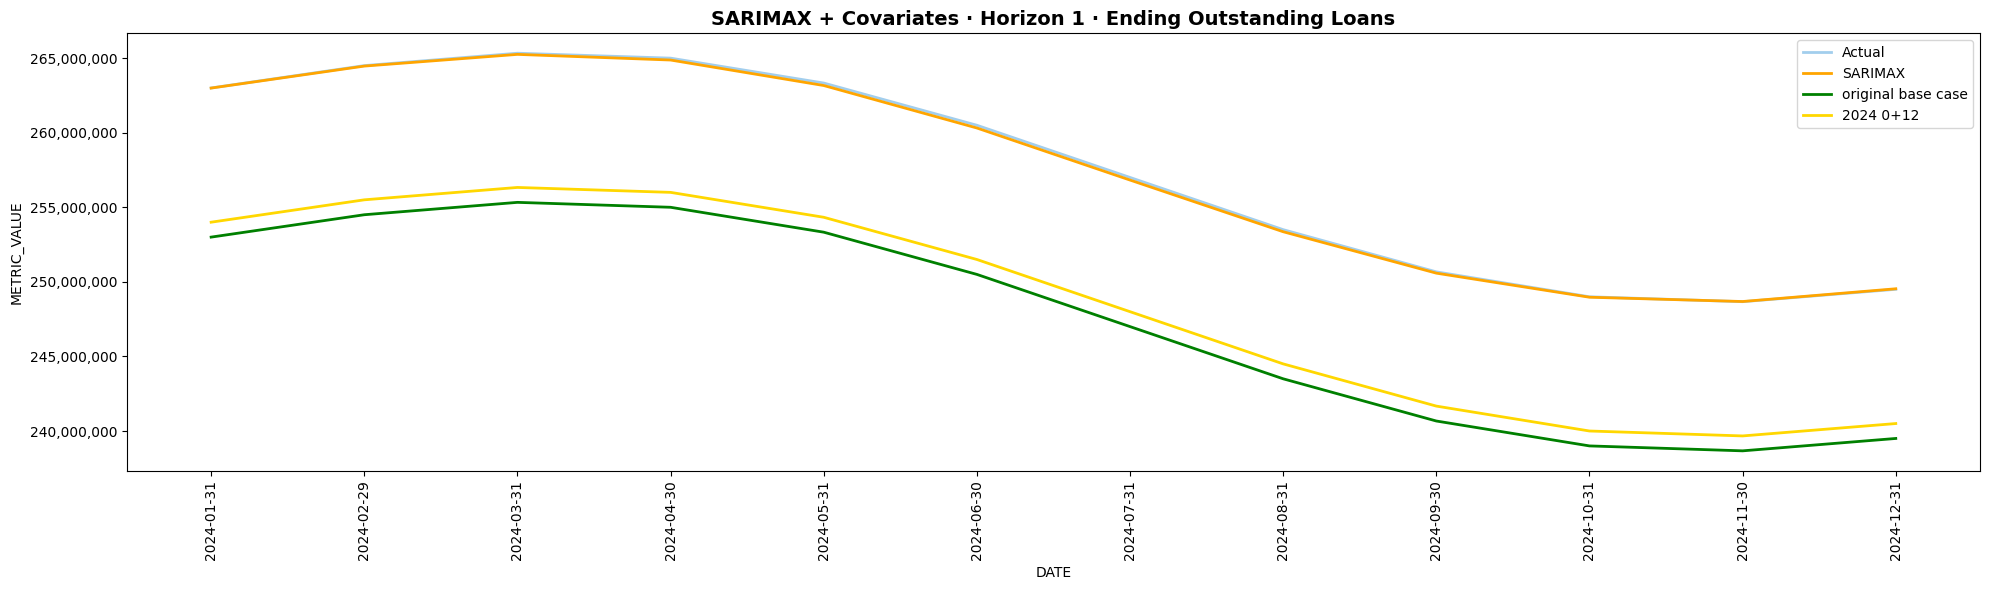

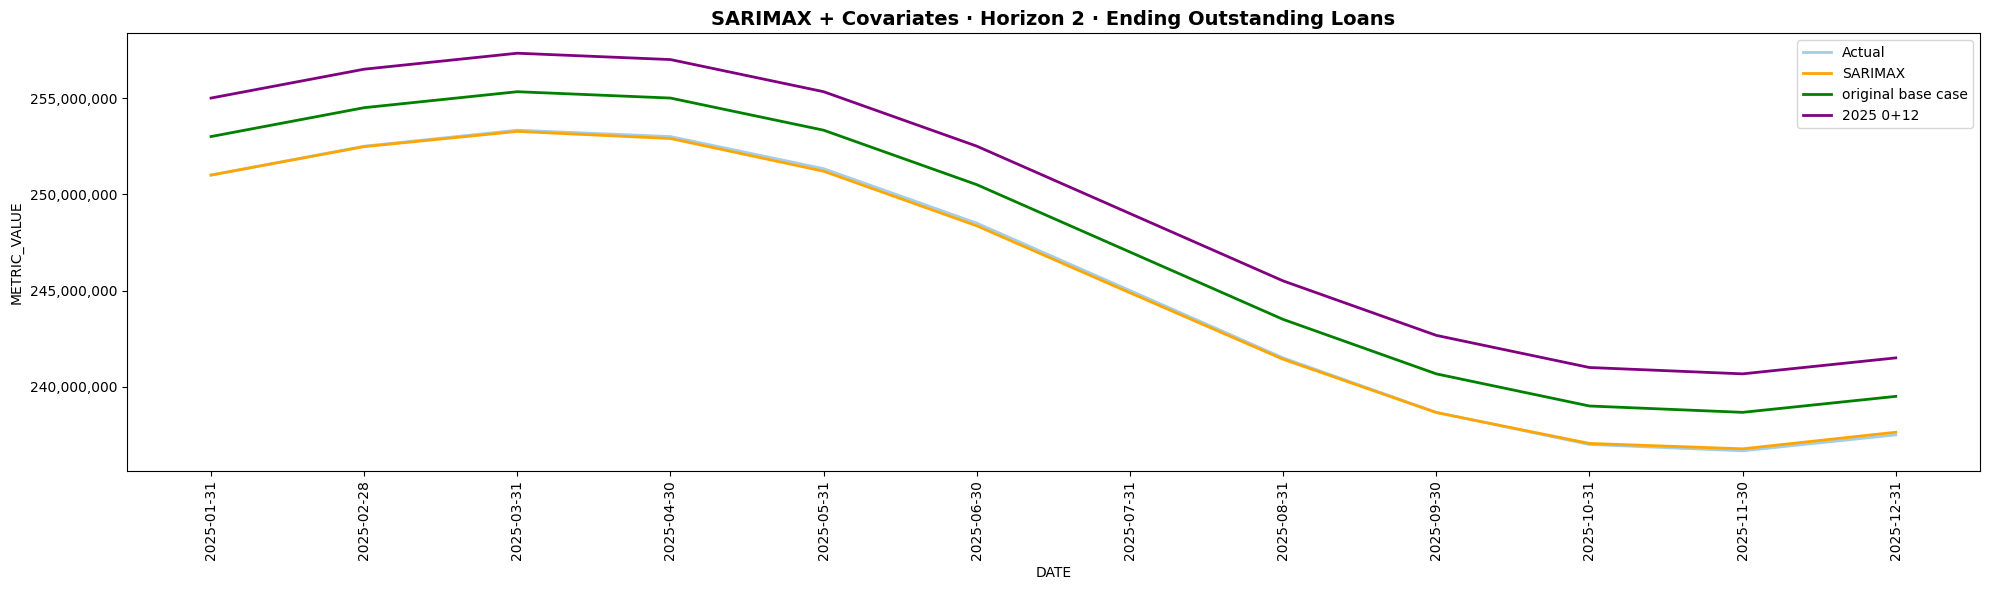

In [128]:
plot_results(pred_df_h1, f"SARIMAX + Covariates · Horizon 1 · {TARGET_METRIC}")
plot_results(pred_df_h2, f"SARIMAX + Covariates · Horizon 2 · {TARGET_METRIC}")

## 11. Inference horizon forecasting
When lag features are included in `exog` (e.g. `lag_1`, `lag_12`),
the model cannot produce all steps in one shot because each step's
lag feature depends on the preceding predicted value.

`recursive_forecast_with_exog` implements a step-by-step loop:
1. Compute next-step exog from the current prediction history
2. Call `get_forecast(steps=1)` with that exog
3. Append the prediction to history
4. Repeat

Covariate values for the test period come from `cov_forecasts_inf`.


### 11.1  Recursive forecast for inference horizon

In [129]:
# Fit the final inference model (does NOT forecast yet)
p_inf, d_inf, q_inf = int(best_params.p), int(best_params.d), int(best_params.q)
P_inf, D_inf, Q_inf = int(best_params.P), int(best_params.D), int(best_params.Q)

result_inf = SARIMAX(
    train_y_inf, exog=train_exog_inf,
    order=(p_inf, d_inf, q_inf), seasonal_order=(P_inf, D_inf, Q_inf, _M),
    trend="n", enforce_stationarity=False, enforce_invertibility=False,
).fit(disp=False)

# Pre-build the non-lag exog portion for inference test period
non_lag_cols_inf = [c for c in train_exog_inf.columns if c not in LAG_COLS]
future_cov_df_inf = test_exog_inf[non_lag_cols_inf]
all_cols_inf = list(train_exog_inf.columns)

# Recursive step-by-step forecast
fc_inf = recursive_forecast_with_exog(
    result_obj     = result_inf,
    history        = train_y_inf,
    future_index   = test_inf.index,
    future_cov_df  = future_cov_df_inf,
    lag_cols       = LAG_COLS,
    all_exog_cols  = all_cols_inf,
)

pred_df_inf = build_pred_df(fc_inf.values, test_y_inf, model_label="SARIMAX")
print("Recursive inference forecast complete.")


Recursive inference forecast complete.


### 11.2 Add Benchmark Series

In [130]:
benchmark_frames = []
for label in BENCHMARK_LABELS_INFER:
    bdf = get_benchmark(
        metric_df, portfolio, sub_portfolio,
        TARGET_METRIC, test_y_inf.index, label,
    )
    if not bdf.empty:
        benchmark_frames.append(bdf)

pred_df_inf = build_pred_df(
    forecast_values = pred_df_inf[pred_df_inf["FORECAST_TYPE"] == "SARIMAX"]["METRIC_VALUE"].values,
    test_series     = test_y_inf,
    model_label     = "SARIMAX",
    benchmark_dfs   = benchmark_frames,
)


### 11.3 Error metrics

In [131]:

# Inference metrics (partial actuals are ok)
clean_inf = drop_missing_actuals(pred_df_inf)
if clean_inf[clean_inf["FORECAST_TYPE"] == "Actual"].empty:
    print("\nInference - no actuals available for evaluation.")
else:
    evaluate_pred_df(
        clean_inf,
        ["SARIMAX"] + BENCHMARK_LABELS_INFER,
        TARGET_METRIC,
    )



═══════════════════════════════════════════════════════
  Error Metrics — Ending Outstanding Loans
═══════════════════════════════════════════════════════
  SARIMAX
    MAPE  : 19.97%
    SMAPE : 22.18%
    MAE   :       59,936,714
    RMSE  :       59,943,826
  2026 0+12 — no data
  original base case — no data
═══════════════════════════════════════════════════════


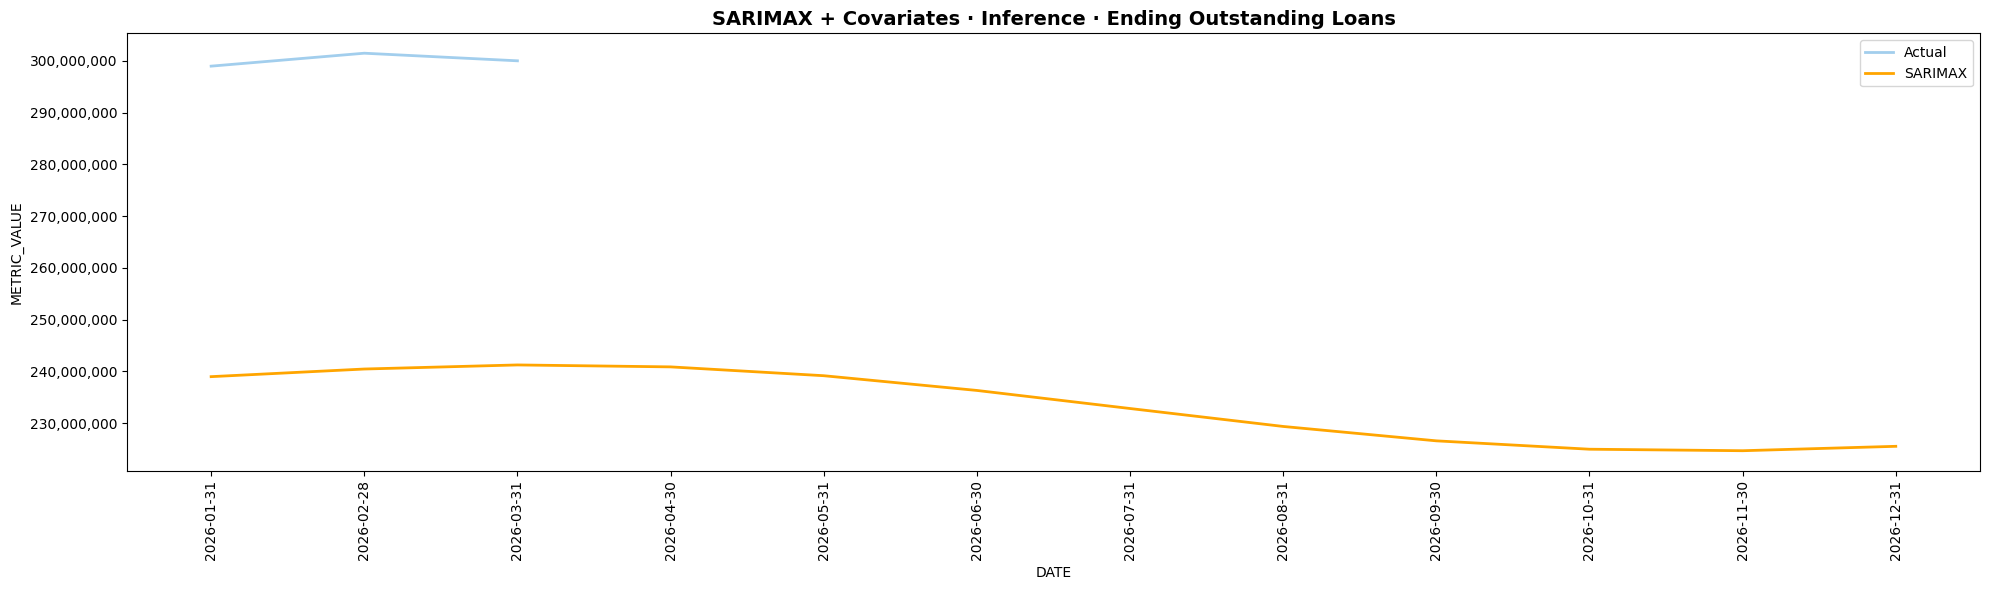

In [132]:
plot_results(pred_df_inf, f"SARIMAX + Covariates · Inference · {TARGET_METRIC}")

## 12 · Export Forecast

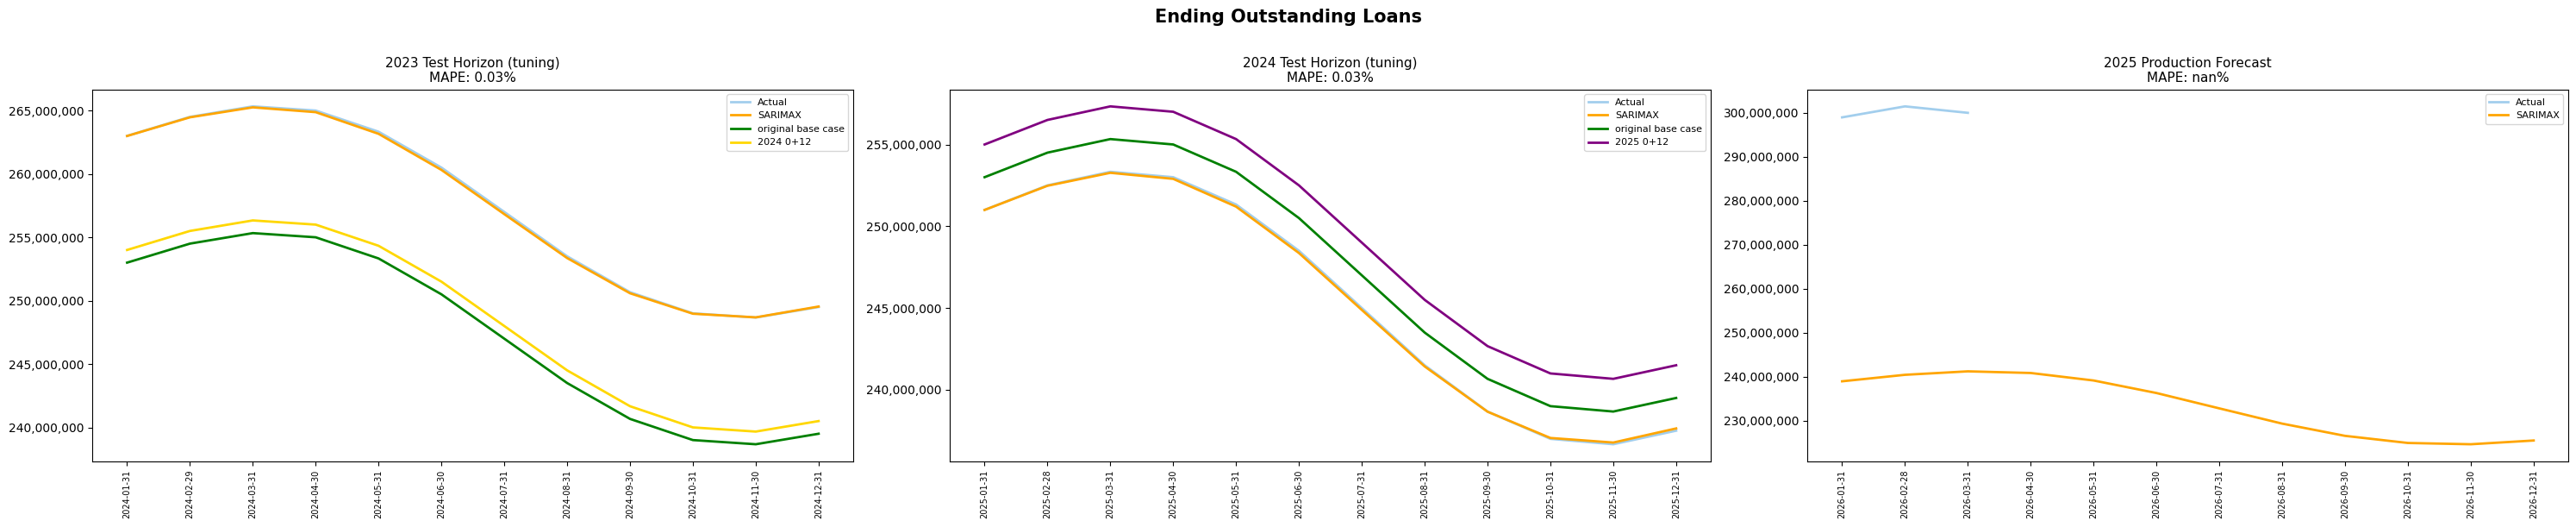

In [133]:
plot_all_horizons(
    pred_2024     = pred_df_h2,
    pred_2025     = pred_df_inf,
    target_metric = TARGET_METRIC,
    pred_2023     = pred_df_h1 if WEIGHTED_TUNING else None,
)


In [134]:
# print the final model summary for diagnostics
print(result_inf.summary())

                                      SARIMAX Results                                      
Dep. Variable:            Ending Outstanding Loans   No. Observations:                   25
Model:             SARIMAX(1, 0, 1)x(1, 0, [], 12)   Log Likelihood                -175.560
Date:                             Wed, 29 Apr 2026   AIC                            367.120
Time:                                     12:18:11   BIC                            370.999
Sample:                                 12-31-2023   HQIC                           365.683
                                      - 12-31-2025                                         
Covariance Type:                               opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
60+ DQ Rate  3.596e+08        nan        nan        nan         nan         nan
lag_1           0.9759  

In [ ]:
out = (
    pred_df_inf[pred_df_inf["FORECAST_TYPE"] == "SARIMAX"]
    [["DATE", "METRIC_VALUE"]]
    .rename(columns={"METRIC_VALUE": TARGET_METRIC})
)
file_name = f"{TARGET_METRIC.replace(' ', '_')}_inference_covariate_forecast.csv"
out.to_csv(file_name, index=False)
print("Saved:", file_name)
out
